In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import model_from_json, load_model
from tensorflow.keras.preprocessing.image import DirectoryIterator,ImageDataGenerator, load_img, img_to_array
import cv2
import tensorflow as tf
from PIL import Image

In [2]:
model = load_model('./models/resnet50_78627.h5')

In [3]:
test_path = './images/test/'

In [4]:
test_datagen = ImageDataGenerator(rescale=1./255, 
                                   brightness_range=[0.2,1.0],
                                   rotation_range=30,
                                   shear_range=0.2,
                                   channel_shift_range=10
                                  )

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(48,48),
    seed=42,
    color_mode='rgb'
)

Found 3546 images belonging to 8 classes.


In [12]:
def evaluate_model(model, test=test_gen):
    loss, acc = model.evaluate(test, verbose=1)
    return loss, acc

In [6]:
class_labels = list(test_gen.class_indices.keys())

In [7]:
face_cascade = cv2.CascadeClassifier('./haarcascade_frontalface_default.xml')

In [8]:
def get_emotion_from_image(img):
    results = face_cascade.detectMultiScale(img, scaleFactor=1.05, minNeighbors=12, minSize=(48,48))
    for (x,y,width,height) in results:
        fc = img[y:y+height, x:x+width]
        roi = np.resize(fc,(48,48,3)).reshape(-1,48,48,3)
        pred = model.predict(roi)
        label = class_labels[pred.argmax()]
        
        cv2.putText(img, label, (x, y), cv2.FONT_HERSHEY_SIMPLEX,2,(255,0,0),3)
        cv2.rectangle(img, 
                      (x,y), 
                      (x+width, y+height), 
                      (0,0,255),
                      2)
    return img

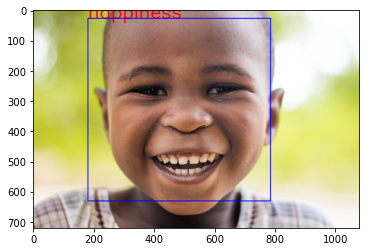

In [9]:
img = cv2.cvtColor(cv2.imread('./happy.jpg'),cv2.COLOR_BGR2RGB)
face = get_emotion_from_image(img)
plt.imshow(face)

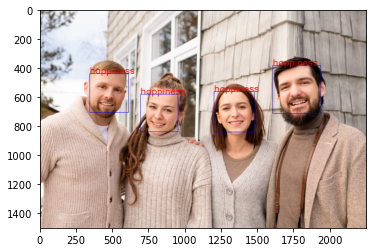

In [10]:
grp_img = cv2.cvtColor(cv2.imread('./group_happy.jpeg'),cv2.COLOR_BGR2RGB)
grp_photo = get_emotion_from_image(grp_img)
plt.imshow(grp_photo)

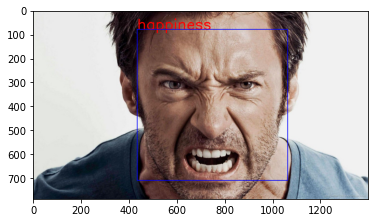

In [11]:
anger_img = cv2.cvtColor(cv2.imread('./anger.jpeg'),cv2.COLOR_RGB2BGR)
anger_result = get_emotion_from_image(anger_img)
plt.imshow(anger_result)

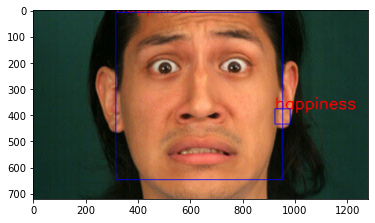

In [182]:
fear_img = cv2.cvtColor(cv2.imread('./fear.jpg'), cv2.COLOR_BGR2RGB)
fear_result = get_emotion_from_image(fear_img)
plt.imshow(fear_result)

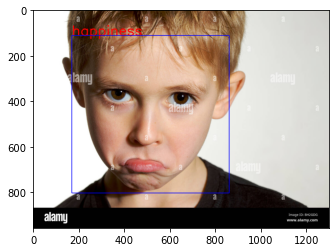

In [183]:
sad_img = cv2.cvtColor(cv2.imread('./sadness.jpg'), cv2.COLOR_BGR2RGB)
sad_result = get_emotion_from_image(sad_img)
plt.imshow(sad_result)

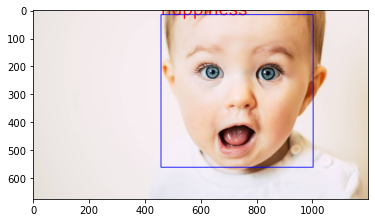

In [130]:
surprise_img = cv2.cvtColor(cv2.imread('./surprise.jpg'), cv2.COLOR_BGR2RGB)
surprise_result = get_face(surprise_img)
plt.imshow(surprise_result)

In [24]:
evaluate_model(load_model('./resnet50_78339.h5'))

111/111 [==============================] - 5s 34ms/step - loss: 0.7830 - accuracy: 0.7724


(0.7829882502555847, 0.7724196314811707)

In [13]:
evaluate_model(load_model('./resnet152_1_checkpoint.h5'))

111/111 [==============================] - 4s 33ms/step - loss: 0.7831 - accuracy: 0.7719


(0.7830901145935059, 0.7718555927276611)

In [14]:
evaluate_model(load_model('./resnet152_checkpoint.h5'))

111/111 [==============================] - 7s 38ms/step - loss: 3.1796 - accuracy: 0.3542


(3.1795668601989746, 0.35420191287994385)

In [15]:
evaluate_model(load_model('./resnet50_1_checkpoint.h5'))

111/111 [==============================] - 4s 33ms/step - loss: 0.7548 - accuracy: 0.7651


(0.7548149228096008, 0.7650874257087708)

In [16]:
evaluate_model(load_model('./resnet50_checkpoint.h5'))

111/111 [==============================] - 5s 34ms/step - loss: 0.7487 - accuracy: 0.7417


(0.748694896697998, 0.7416807413101196)

In [17]:
evaluate_model(load_model('./resnet50_model.h5'))

111/111 [==============================] - 4s 33ms/step - loss: 0.7273 - accuracy: 0.7625


(0.7273238301277161, 0.7625493407249451)

In [18]:
evaluate_model(load_model('./custom_checkpoint.h5'))

111/111 [==============================] - 4s 34ms/step - loss: 0.6876 - accuracy: 0.7518


(0.6875644326210022, 0.7518330216407776)

In [19]:
evaluate_model(load_model('./vgg16_1_checkpoint.h5'))

111/111 [==============================] - 4s 34ms/step - loss: 0.8116 - accuracy: 0.7132


(0.811623752117157, 0.7131979465484619)

In [20]:
evaluate_model(load_model('./vgg16_checkpoint.h5'))

111/111 [==============================] - 4s 32ms/step - loss: 0.8494 - accuracy: 0.7095


(0.8494424819946289, 0.709531843662262)

In [21]:
evaluate_model(load_model('./vgg_f_checkpoint.h5'))

111/111 [==============================] - 4s 31ms/step - loss: 1.3304 - accuracy: 0.5014


(1.3304380178451538, 0.5014100670814514)

In [22]:
evaluate_model(load_model('./vgg_test_1_checkpoint.h5'))

111/111 [==============================] - 4s 31ms/step - loss: 1.1307 - accuracy: 0.6063


(1.1306986808776855, 0.6063169836997986)

In [23]:
evaluate_model(load_model('./vggbasic_checkpoint.h5'))

111/111 [==============================] - 4s 32ms/step - loss: 1.6296 - accuracy: 0.3559


(1.6295859813690186, 0.35589396953582764)

In [25]:
evaluate_model(load_model('./rn50_test_1_checkpoint.h5'))

111/111 [==============================] - 5s 33ms/step - loss: 0.7602 - accuracy: 0.7580


(0.7601979970932007, 0.7580372095108032)

In [ ]:
# Plot confusion matrix
# Do misclassification analysis
# Do face detection on image, before using predict function
# Site dev